# Модель Пуассона

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson
import glob
import warnings
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120
})


## 1. Загрузка данных и настройка бэк-теста


In [ ]:
LEAGUES = {
    'BL':  {'name': 'Бундеслига',   'path': 'data/BL/*.csv'},
    'EPL': {'name': 'Премьер-лига', 'path': 'data/EPL/*.csv'},
    'SA':  {'name': 'Серия А',      'path': 'data/SA/*.csv'},
    'LA':  {'name': 'Ла Лига',      'path': 'data/LA/*.csv'},
    'LG1': {'name': 'Лига 1',       'path': 'data/LG1/*.csv'},
}

TEST_MATCHES_COUNT = 300

MIN_TRAIN_SIZE = 300

RETRAIN_EVERY = 10 

def load_all_data(info):
    files = sorted(glob.glob(info['path']))
    frames = []
    for f in files:
        try:
            df = pd.read_csv(f)
            cols_needed = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']
            cols_bk = ['B365H', 'B365D', 'B365A']
            cols = [c for c in cols_needed + cols_bk if c in df.columns]
            frames.append(df[cols])
        except Exception as e:
            pass
    
    data = pd.concat(frames, ignore_index=True).dropna(subset=['FTHG', 'FTAG'])
    data['FTHG'] = data['FTHG'].astype(int)
    data['FTAG'] = data['FTAG'].astype(int)
    
    for fmt in ['%d/%m/%Y', '%d/%m/%y', '%Y-%m-%d']:
        try:
            data['Date'] = pd.to_datetime(data['Date'], format=fmt)
            break
        except:
            continue
    else:
        data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
    
    data = data.sort_values('Date').reset_index(drop=True)
    return data

all_data = {}
for code_name, info in LEAGUES.items():
    data = load_all_data(info)
    all_data[code_name] = data
    
    n_test = min(TEST_MATCHES_COUNT, len(data) - MIN_TRAIN_SIZE)
    test_start = len(data) - n_test
    
    print(f"{info['name']:15s}: {len(data)} матчей всего, "
          f"тест: последние {n_test} матчей "
          f"({data.iloc[test_start]['Date'].date()} -- {data.iloc[-1]['Date'].date()})")


Бундеслига     : 1458 матчей всего, тест: последние 300 матчей (2025-03-29 -- 2026-03-15)
Премьер-лига   : 1821 матчей всего, тест: последние 300 матчей (2025-08-16 -- 2026-03-16)
Серия А        : 1810 матчей всего, тест: последние 300 матчей (2025-05-23 -- 2026-03-16)
Ла Лига        : 1800 матчей всего, тест: последние 300 матчей (2025-05-18 -- 2026-03-16)
Лига 1         : 1605 матчей всего, тест: последние 300 матчей (2025-03-30 -- 2026-03-15)


## 2. Модель и rolling backtest


In [ ]:
def train_poisson_model(train_data):
    goal_data = pd.concat([
        train_data[['HomeTeam', 'AwayTeam', 'FTHG']].assign(home=1).rename(
            columns={'HomeTeam': 'team', 'AwayTeam': 'opponent', 'FTHG': 'goals'}),
        train_data[['AwayTeam', 'HomeTeam', 'FTAG']].assign(home=0).rename(
            columns={'AwayTeam': 'team', 'HomeTeam': 'opponent', 'FTAG': 'goals'})
    ])
    
    model = smf.glm(
        formula="goals ~ home + team + opponent",
        data=goal_data,
        family=sm.families.Poisson()
    ).fit()
    return model


def predict_match(model, home_team, away_team, max_goals=10):
    try:
        lambda_home = model.predict(pd.DataFrame({
            'team': [home_team], 'opponent': [away_team], 'home': [1]
        })).values[0]
        
        lambda_away = model.predict(pd.DataFrame({
            'team': [away_team], 'opponent': [home_team], 'home': [0]
        })).values[0]
    except Exception:
        return None
    
    home_probs = [poisson.pmf(i, lambda_home) for i in range(max_goals + 1)]
    away_probs = [poisson.pmf(i, lambda_away) for i in range(max_goals + 1)]
    matrix = np.outer(home_probs, away_probs)
    
    p_home = np.sum(np.tril(matrix, -1))
    p_draw = np.sum(np.diag(matrix))
    p_away = np.sum(np.triu(matrix, 1))
    
    return {
        'p_home': p_home, 'p_draw': p_draw, 'p_away': p_away,
        'lambda_home': lambda_home, 'lambda_away': lambda_away
    }


def rolling_backtest(data, n_test, retrain_every=10, min_train=300):
    n = len(data)
    split_start = n - n_test
    
    if split_start < min_train:
        split_start = min_train
    
    results = []
    current_model = None
    last_train_idx = -1
    
    for i in range(split_start, n):
        if current_model is None or (i - last_train_idx) >= retrain_every:
            train_data = data.iloc[:i]
            try:
                current_model = train_poisson_model(train_data)
                last_train_idx = i
            except Exception as e:
                continue
        
        row = data.iloc[i]
        pred = predict_match(current_model, row['HomeTeam'], row['AwayTeam'])
        
        if pred is None:
            continue
        
        if row['FTHG'] > row['FTAG']:
            actual = 'H'
        elif row['FTHG'] == row['FTAG']:
            actual = 'D'
        else:
            actual = 'A'
        
        result = {
            'match_idx': i,
            'Date': row['Date'],
            'HomeTeam': row['HomeTeam'],
            'AwayTeam': row['AwayTeam'],
            'FTHG': row['FTHG'],
            'FTAG': row['FTAG'],
            'actual': actual,
            'train_size': i, 
            **pred
        }
        
        for col in ['B365H', 'B365D', 'B365A']:
            if col in data.columns and pd.notna(row.get(col)):
                result[col] = row[col]
        
        results.append(result)
    
    return pd.DataFrame(results)


## 3. Запуск rolling backtest по всем лигам


In [ ]:
predictions = {}

for code_name, info in LEAGUES.items():
    data = all_data[code_name]
    n_test = min(TEST_MATCHES_COUNT, len(data) - MIN_TRAIN_SIZE)
    
    print(f"\n{'='*60}")
    print(f"{info['name']}")
    print(f"{'='*60}")
    
    preds = rolling_backtest(
        data, 
        n_test=n_test, 
        retrain_every=RETRAIN_EVERY, 
        min_train=MIN_TRAIN_SIZE
    )
    
    predictions[code_name] = preds
    print(f"  Получено {len(preds)} предсказаний")
    print(f"  Период: {preds['Date'].min().date()} -- {preds['Date'].max().date()}")
    print(f"  Модель переобучалась {preds['train_size'].nunique()} раз")



Бундеслига:
  Получено 298 предсказаний
  Период: 2025-03-29 -- 2026-03-15
  Модель переобучалась 298 раз

Премьер-лига:
  Получено 299 предсказаний
  Период: 2025-08-16 -- 2026-03-16
  Модель переобучалась 299 раз

Серия А:
  Получено 299 предсказаний
  Период: 2025-05-23 -- 2026-03-16
  Модель переобучалась 299 раз

Ла Лига:
  Получено 299 предсказаний
  Период: 2025-05-18 -- 2026-03-16
  Модель переобучалась 299 раз

Лига 1:
  Получено 298 предсказаний
  Период: 2025-03-30 -- 2026-03-15
  Модель переобучалась 298 раз


## 4. Метрики качества

Вычисление метрик Accuracy, Log-Loss, Brier Score, RPS на всех предсказаниях бэк-теста


In [ ]:
def compute_metrics(preds_df):
    n = len(preds_df)
    if n == 0:
        return {}
    
    p_matrix = preds_df[['p_home', 'p_draw', 'p_away']].values
    
    actual_onehot = np.zeros((n, 3))
    for i, outcome in enumerate(preds_df['actual']):
        if outcome == 'H': actual_onehot[i, 0] = 1
        elif outcome == 'D': actual_onehot[i, 1] = 1
        else: actual_onehot[i, 2] = 1
    
    accuracy = np.mean(np.argmax(p_matrix, axis=1) == np.argmax(actual_onehot, axis=1))
    
    p_clipped = np.clip(p_matrix, 1e-10, 1.0)
    log_loss = -np.mean(np.sum(actual_onehot * np.log(p_clipped), axis=1))
    
    brier = np.mean(np.sum((p_matrix - actual_onehot) ** 2, axis=1))
    
    cum_pred = np.cumsum(p_matrix[:, :2], axis=1)
    cum_actual = np.cumsum(actual_onehot[:, :2], axis=1)
    rps = np.mean(np.sum((cum_pred - cum_actual) ** 2, axis=1) / 2)
    
    return {
        'Accuracy': round(accuracy, 4),
        'Log-Loss': round(log_loss, 4),
        'Brier Score': round(brier, 4),
        'RPS': round(rps, 4),
        'N': n
    }

baseline_logloss = -np.log(1/3)

metrics_rows = []
for code_name, info in LEAGUES.items():
    m = compute_metrics(predictions[code_name])
    m['Лига'] = info['name']
    metrics_rows.append(m)

metrics_table = pd.DataFrame(metrics_rows)[['Лига', 'N', 'Accuracy', 'Log-Loss', 'Brier Score', 'RPS']]
print(f"Для случайного выбора наугад Log-Loss = {baseline_logloss:.4f}")
print()
print("Модель Пуассона:")
metrics_table


Для случайного выбора наугад Log-Loss = 1.0986

Модель Пуассона:


,Лига,N,Accuracy,Log-Loss,Brier Score,RPS
0,Бундеслига,298,0.5134,1.0510,0.5854,0.1978
1,Премьер-лига,299,0.4649,1.1068,0.6260,0.2129
2,Серия А,299,0.4950,0.9913,0.5912,0.2022
3,Ла Лига,299,0.5385,1.0285,0.5715,0.1937
4,Лига 1,298,0.5268,0.9825,0.5846,0.2091


## 5. Калибровка вероятностей



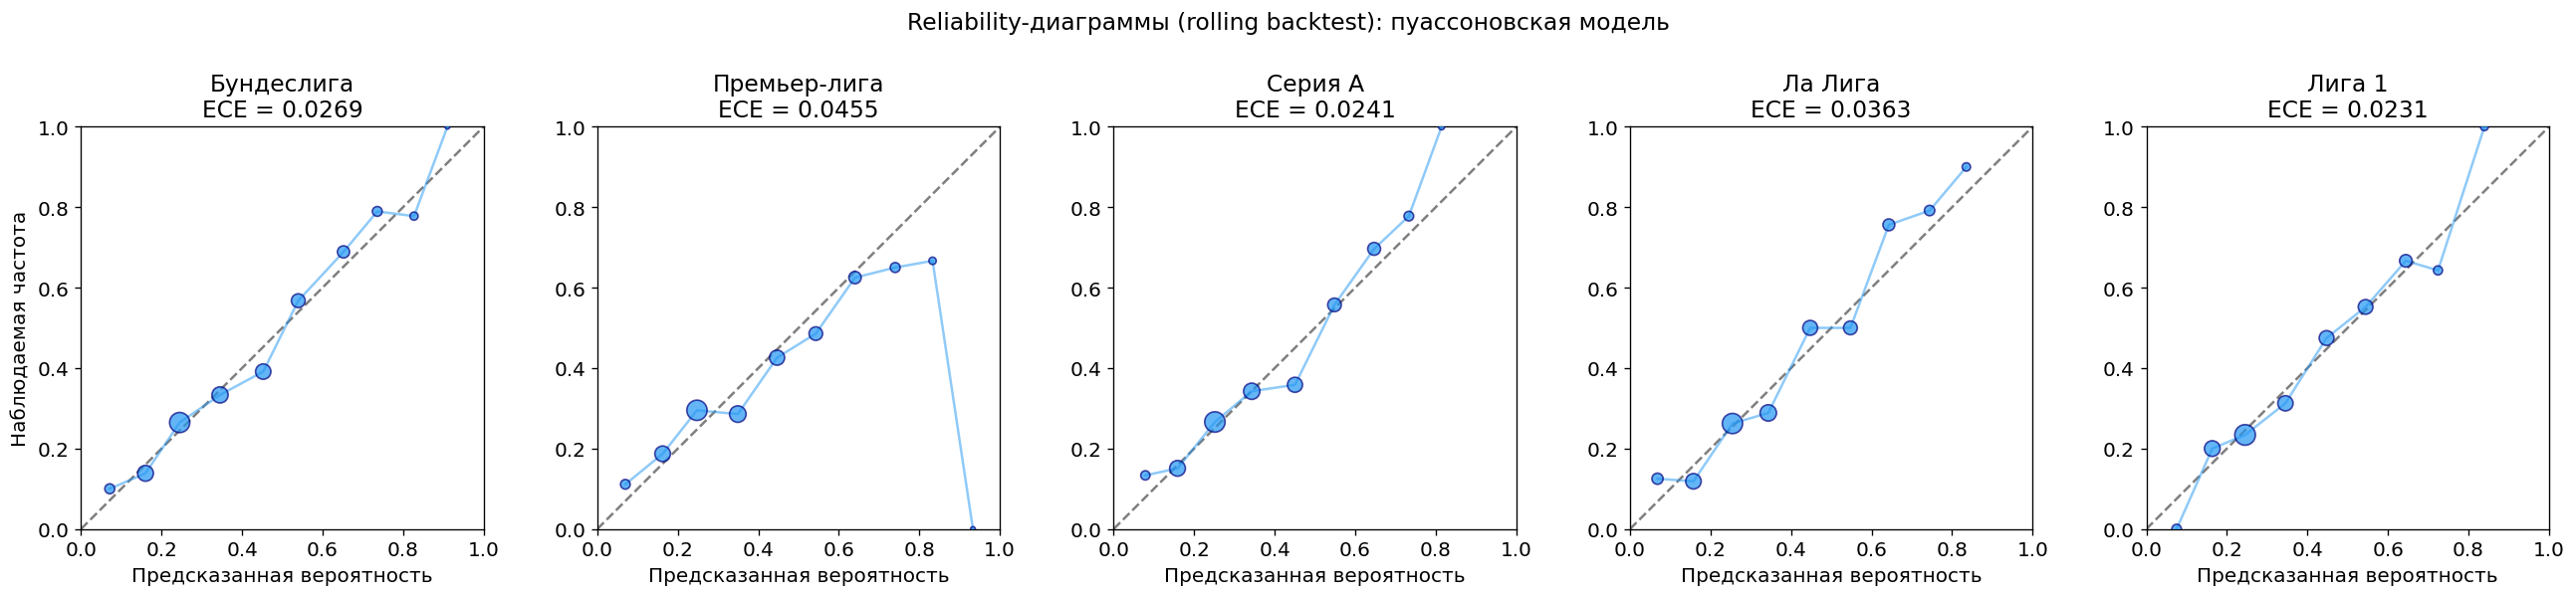

In [ ]:
def calibration_analysis(preds_df, n_bins=10):
    all_probs = []
    all_outcomes = []
    
    for _, row in preds_df.iterrows():
        for prob, label in [(row['p_home'], 'H'), (row['p_draw'], 'D'), (row['p_away'], 'A')]:
            all_probs.append(prob)
            all_outcomes.append(1 if row['actual'] == label else 0)
    
    all_probs = np.array(all_probs)
    all_outcomes = np.array(all_outcomes)
    
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers, bin_freqs, bin_counts = [], [], []
    
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (all_probs >= bin_edges[i]) & (all_probs <= bin_edges[i + 1])
        else:
            mask = (all_probs >= bin_edges[i]) & (all_probs < bin_edges[i + 1])
        
        if mask.sum() > 0:
            bin_centers.append(all_probs[mask].mean())
            bin_freqs.append(all_outcomes[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
            bin_freqs.append(np.nan)
            bin_counts.append(0)
    
    total = sum(bin_counts)
    ece = sum(
        (c / total) * abs(f - p) 
        for p, f, c in zip(bin_centers, bin_freqs, bin_counts) 
        if c > 0 and not np.isnan(f)
    )
    
    return np.array(bin_centers), np.array(bin_freqs), np.array(bin_counts), ece


fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
ece_values = {}

for idx, (code_name, info) in enumerate(LEAGUES.items()):
    ax = axes[idx]
    centers, freqs, counts, ece = calibration_analysis(predictions[code_name])
    ece_values[code_name] = ece
    
    valid = ~np.isnan(freqs)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Идеальная')
    ax.scatter(centers[valid], freqs[valid], s=np.sqrt(counts[valid]) * 8,
               c='#2196F3', alpha=0.7, edgecolors='navy', zorder=5)
    ax.plot(centers[valid], freqs[valid], '-', color='#2196F3', alpha=0.5)
    
    ax.set_title(f"{info['name']}\nECE = {ece:.4f}")
    ax.set_xlabel('Предсказанная вероятность')
    if idx == 0:
        ax.set_ylabel('Наблюдаемая частота')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

plt.suptitle('Reliability-диаграммы (rolling backtest): пуассоновская модель', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('calibration_poisson_rolling.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Сравнение с букмекером


In [ ]:
def compare_with_bookmaker(preds_df):
    """Сравнивает модель с букмекером."""
    if 'B365H' not in preds_df.columns:
        return None
    
    df = preds_df.dropna(subset=['B365H', 'B365D', 'B365A']).copy()
    if len(df) == 0:
        return None

    df['imp_h'] = 1 / df['B365H']
    df['imp_d'] = 1 / df['B365D']
    df['imp_a'] = 1 / df['B365A']
    total_imp = df['imp_h'] + df['imp_d'] + df['imp_a']
    df['fair_h'] = df['imp_h'] / total_imp
    df['fair_d'] = df['imp_d'] / total_imp
    df['fair_a'] = df['imp_a'] / total_imp
    df['margin'] = total_imp - 1
    
    n = len(df)
    actual_oh = np.zeros((n, 3))
    for i, o in enumerate(df['actual']):
        if o == 'H': actual_oh[i, 0] = 1
        elif o == 'D': actual_oh[i, 1] = 1
        else: actual_oh[i, 2] = 1
    
    mp = np.clip(df[['p_home', 'p_draw', 'p_away']].values, 1e-10, 1)
    m_ll = -np.mean(np.sum(actual_oh * np.log(mp), axis=1))
    m_bs = np.mean(np.sum((df[['p_home','p_draw','p_away']].values - actual_oh)**2, axis=1))
    
    bp = np.clip(df[['fair_h', 'fair_d', 'fair_a']].values, 1e-10, 1)
    b_ll = -np.mean(np.sum(actual_oh * np.log(bp), axis=1))
    b_bs = np.mean(np.sum((df[['fair_h','fair_d','fair_a']].values - actual_oh)**2, axis=1))
    
    return {
        'N': n,
        'Ср. маржа, %': round(df['margin'].mean() * 100, 2),
        'Модель LL': round(m_ll, 4),
        'Букмекер LL': round(b_ll, 4),
        'delta LL': round(m_ll - b_ll, 4),
        'Модель BS': round(m_bs, 4),
        'Букмекер BS': round(b_bs, 4),
        'delta BS': round(m_bs - b_bs, 4),
    }

bk_rows = []
for code_name, info in LEAGUES.items():
    r = compare_with_bookmaker(predictions[code_name])
    if r:
        r['Лига'] = info['name']
        bk_rows.append(r)

if bk_rows:
    bk_table = pd.DataFrame(bk_rows)[[
        'Лига', 'N', 'Ср. маржа, %', 
        'Модель LL', 'Букмекер LL', 'delta LL',
        'Модель BS', 'Букмекер BS', 'delta BS'
    ]]
    print("Сравнение с букмекером:")
    print("delta > 0 = модель хуже букмекера")
    print()
    display(bk_table)


Сравнение с букмекером:
delta > 0 = модель хуже букмекера



,Лига,N,"Ср. маржа, %",Модель LL,Букмекер LL,delta LL,Модель BS,Букмекер BS,delta BS
0,Бундеслига,298,5.56,1.0510,0.9547,0.0963,0.5854,0.5655,0.0199
1,Премьер-лига,299,5.52,1.1068,1.0211,0.0856,0.6260,0.6145,0.0116
2,Серия А,299,5.49,0.9913,0.9747,0.0166,0.5912,0.5789,0.0123
3,Ла Лига,299,5.63,1.0285,0.9492,0.0794,0.5715,0.5612,0.0103
4,Лига 1,298,5.57,0.9825,0.9626,0.0199,0.5846,0.5706,0.0140


## 7. Анализ стабильности во времени

Скользящий Log-Loss c окном 50 матчей покажет, наличие деградации

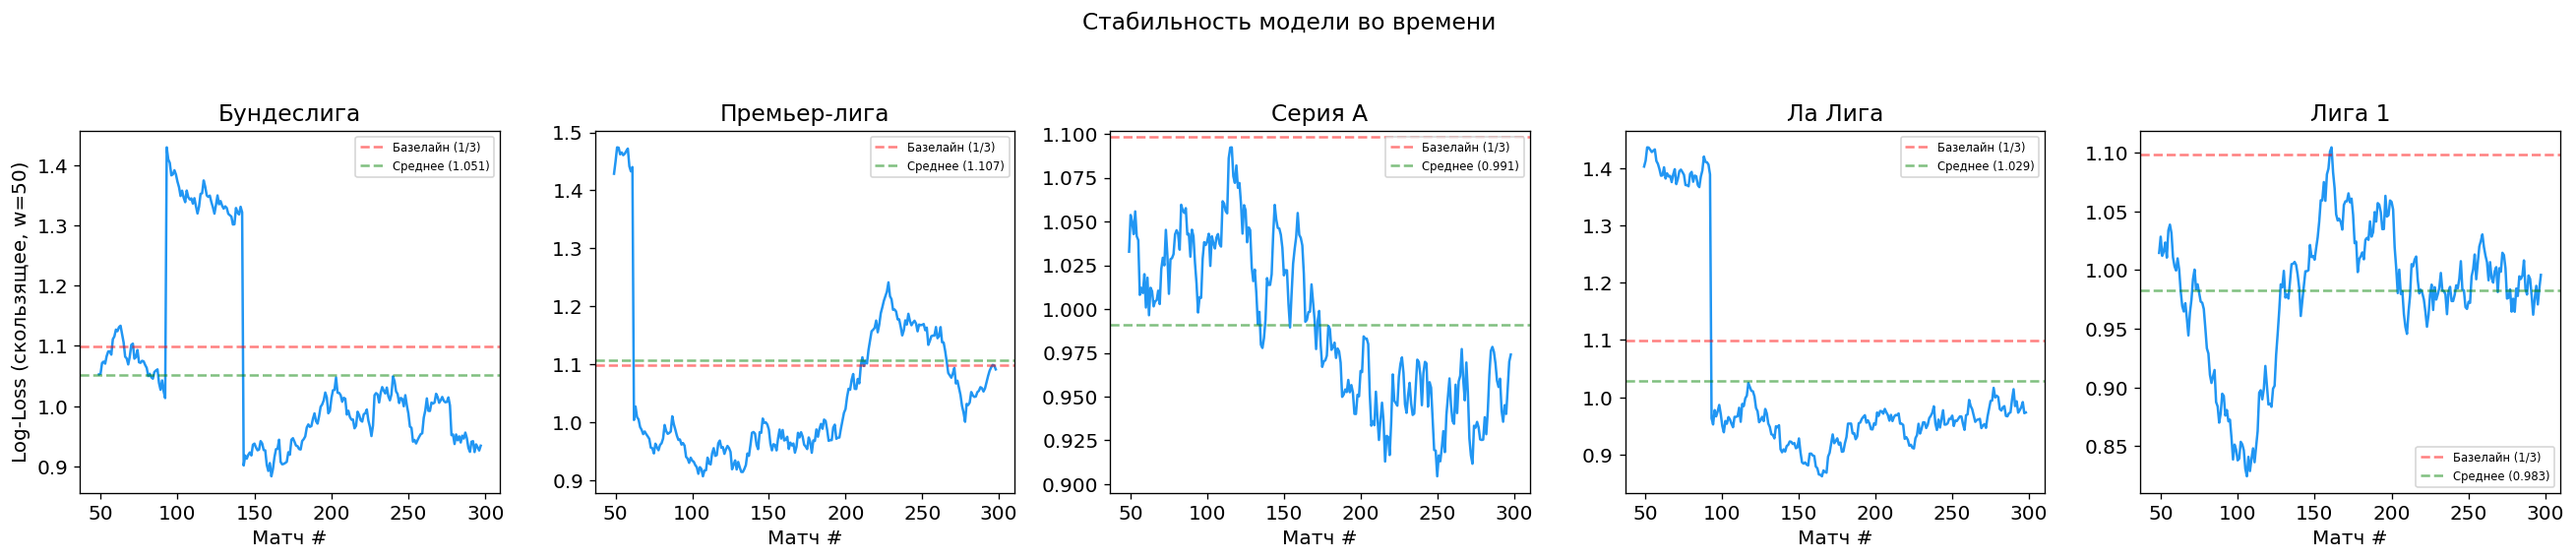

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for idx, (code_name, info) in enumerate(LEAGUES.items()):
    ax = axes[idx]
    preds = predictions[code_name].copy()
    
    if len(preds) < 50:
        ax.set_title(f"{info['name']}\n(мало данных)")
        continue
    
    p_matrix = preds[['p_home', 'p_draw', 'p_away']].values
    actual_oh = np.zeros((len(preds), 3))
    for i, o in enumerate(preds['actual']):
        if o == 'H': actual_oh[i, 0] = 1
        elif o == 'D': actual_oh[i, 1] = 1
        else: actual_oh[i, 2] = 1
    
    per_match_ll = -np.sum(actual_oh * np.log(np.clip(p_matrix, 1e-10, 1)), axis=1)
    
    window = 50
    rolling_ll = pd.Series(per_match_ll).rolling(window, min_periods=window).mean()
    
    ax.plot(range(len(rolling_ll)), rolling_ll, color='#2196F3', linewidth=1.5)
    ax.axhline(y=np.log(3), color='red', linestyle='--', alpha=0.5, label='Базелайн (1/3)')
    ax.axhline(y=per_match_ll.mean(), color='green', linestyle='--', alpha=0.5, label=f'Среднее ({per_match_ll.mean():.3f})')
    
    ax.set_title(info['name'])
    ax.set_xlabel('Матч #')
    if idx == 0:
        ax.set_ylabel(f'Log-Loss (скользящее, w={window})')
    ax.legend(fontsize=7)

plt.suptitle('Стабильность модели во времени', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('temporal_stability_poisson.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Итоговая сводка


In [ ]:
summary_rows = []
for code_name, info in LEAGUES.items():
    row = compute_metrics(predictions[code_name])
    row['Лига'] = info['name']
    row['ECE'] = round(ece_values.get(code_name, np.nan), 4)
    
    bk = compare_with_bookmaker(predictions[code_name])
    if bk:
        row['delta LL vs бк'] = bk['delta LL']
        row['delta BS vs бк'] = bk['delta BS']
    
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
cols = ['Лига', 'N', 'Accuracy', 'Log-Loss', 'Brier Score', 'RPS', 'ECE']
if 'delta LL vs бк' in summary.columns:
    cols += ['delta LL vs бк', 'delta BS vs бк']

print("Итоговая таблица")
summary[cols]


Итоговая таблица


,Лига,N,Accuracy,Log-Loss,Brier Score,RPS,ECE,delta LL vs бк,delta BS vs бк
0,Бундеслига,298,0.5134,1.0510,0.5854,0.1978,0.0269,0.0963,0.0199
1,Премьер-лига,299,0.4649,1.1068,0.6260,0.2129,0.0455,0.0856,0.0116
2,Серия А,299,0.4950,0.9913,0.5912,0.2022,0.0241,0.0166,0.0123
3,Ла Лига,299,0.5385,1.0285,0.5715,0.1937,0.0363,0.0794,0.0103
4,Лига 1,298,0.5268,0.9825,0.5846,0.2091,0.0231,0.0199,0.0140


In [ ]:
for code_name in LEAGUES:
    predictions[code_name].to_csv(f'predictions_poisson_rolling_{code_name}.csv', index=False)